import libararies

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

connect with database

In [2]:
conn = sqlite3.connect(r'C:\Users\hamen\OneDrive\Desktop\projects set\project5\swiggy_database.db')


Check connection

In [3]:
q1 = 'select*from swaggy_db;'
pd.read_sql(q1,conn)


,order_id,customer_id,order_date,num__order_amount,num__delivery_time_mins,num__rating,cat__city,cat__restaurant,cat__cuisine,cat__order_status,cat__payment_mode,months,years
0,40,1474,2024-01-04 00:00:00,709.13,28.0,4.7,Mumbai,Biryani House,North Indian,Pending,Wallet,January,2024
1,1603,1936,2024-02-02 00:00:00,938.23,40.0,3.6,Bangalore,Spice Hub,North Indian,Pending,Wallet,February,2024
2,3344,1252,2024-01-17 00:00:00,470.62,43.0,4.7,Mumbai,Pizza World,Desserts,Cancelled,UPI,January,2024
3,4549,1419,2024-04-22 00:00:00,1448.17,23.0,4.2,Mumbai,Biryani House,Desserts,Pending,Wallet,April,2024
4,3610,1630,2024-09-05 00:00:00,567.30,10.0,3.4,Hyderabad,Urban Tadka,unknown,Delivered,Wallet,September,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,221,1573,2024-07-25 00:00:00,1200.82,21.0,1.8,Mumbai,Sushi Zen,North Indian,Cancelled,Cash,July,2024
4996,4464,1652,2024-02-11 00:00:00,124.17,13.0,2.0,Chennai,Biryani House,Desserts,Pending,Cash,February,2024
4997,4501,1550,2024-04-02 00:00:00,334.96,26.0,1.7,unknown,Spice Hub,Chinese,Pending,UPI,April,2024
4998,3959,1983,2024-05-26 00:00:00,109.23,59.0,1.6,Mumbai,Sushi Zen,Fast Food,Delivered,Cash,May,2024


Total Revenue

In [4]:
toa = """ 
select sum(num__order_amount) as total_revenue from swaggy_db;
"""
pd.read_sql(toa,conn)

,total_revenue
0,3977829.82


The platform generated a total revenue of ₹3977829.82, indicating overall business performance and market demand.

Total Orders

In [5]:
to = """ select count(order_id) as total_orders from swaggy_db;"""
pd.read_sql(to,conn)


,total_orders
0,5000


A total of 5000 orders were placed, reflecting the platform’s usage and customer engagement level.

Order Status

In [56]:
ors = """  
select
cat__order_status as order_status,
count(order_id) as num_of_order
from swaggy_db
group by cat__order_status
order by count(order_id) desc;
"""
df = pd.read_sql(ors,conn)
df

,order_status,num_of_order
0,Cancelled,1681
1,Pending,1666
2,Delivered,1653


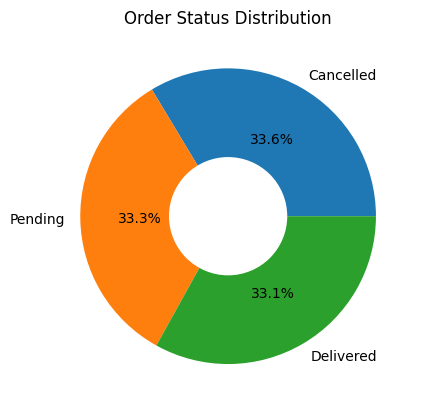

In [57]:
plt.pie(df['num_of_order'], labels=df['order_status'], autopct='%1.1f%%')
plt.gca().add_artist(plt.Circle((0,0),0.4,fc='white'))
plt.title('Order Status Distribution')
plt.show()

Most orders are Cancelled , and noticeable portion is Deliverd, which may impact revenue and customer trust.

Order placed in each months

In [58]:
opem = """ 
select months,count(order_id) as total_orders
from swaggy_db
group by months
order by count(order_id) desc;
"""
df = pd.read_sql(opem,conn)
df

,months,total_orders
0,September,452
1,August,445
2,April,445
3,January,430
4,May,425
5,October,419
6,July,416
7,March,413
8,June,396
9,February,395


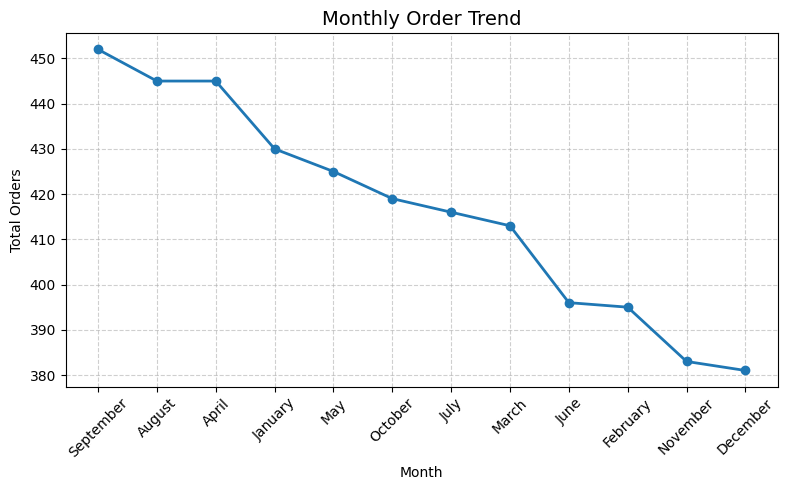

In [61]:
plt.figure(figsize=(8,5))

plt.plot(
    df['months'],
    df['total_orders'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Order Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Order volume fluctuates across months, indicating seasonal trends that can be leveraged for targeted promotions and offers.

Total Revenue earn in each months

In [8]:
tsem = """ 
select months,
sum(num__order_amount) Revenue
from swaggy_db
group by months
order by sum(num__order_amount) desc;
"""
pd.read_sql(tsem,conn)

,months,Revenue
0,August,354894.60
1,September,349639.66
2,April,347461.71
3,October,340973.39
4,July,338681.61
5,January,337333.28
6,March,336509.14
7,May,328300.62
8,February,325335.11
9,December,315473.83


Revenue varies across months, indicating seasonal demand patterns that can be leveraged for targeted promotions.

Total orders and revenue by each months

In [9]:
topm = """

select months,
count(order_id) as total_orders,
sum(num__order_amount) as total_revenue 
from swaggy_db
group by months 
order by sum(num__order_amount) desc;

"""

d4 = pd.read_sql(topm,conn)
d4

,months,total_orders,total_revenue
0,August,445,354894.60
1,September,452,349639.66
2,April,445,347461.71
3,October,419,340973.39
4,July,416,338681.61
5,January,430,337333.28
6,March,413,336509.14
7,May,425,328300.62
8,February,395,325335.11
9,December,381,315473.83



Which payment mode is most used?

In [52]:
pm = """ 
select cat__payment_mode as payment_Methods,
count(order_id) as Total_orders
from swaggy_db
group by cat__payment_mode
order by count(order_id) desc;
"""
df = pd.read_sql(pm,conn)
df

,payment_Methods,Total_orders
0,Cash,1291
1,Wallet,1262
2,Card,1247
3,UPI,1200


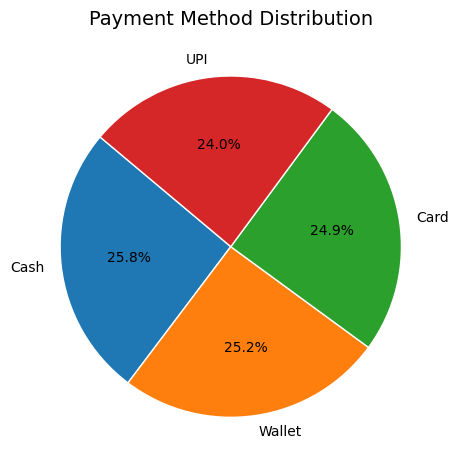

In [55]:

plt.pie(
    df['Total_orders'],
    labels=df['payment_Methods'],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'},
)

plt.title("Payment Method Distribution", fontsize=14)
plt.tight_layout()
plt.show()

Payment mode Cash is the most preferred, suggesting customer trust and convenience in that method. Promotions can be aligned accordingly.

Payment mode Vs rating

In [34]:
cbpar = """ 
select cat__payment_mode as payment_Methods,
avg(num__rating) as Average_rating
from swaggy_db
group by cat__payment_mode
order by avg(num__rating) desc;
"""
pd.read_sql(cbpar,conn)

,payment_Methods,Average_rating
0,Card,3.052285
1,UPI,3.044667
2,Wallet,3.036846
3,Cash,2.972347


Customer ratings show slight variation across payment modes, suggesting that payment experience may influence satisfaction.

Payment mode Vs cancellation

In [36]:
cbpac = """  
select cat__payment_mode as payment_Methods,
count(order_id) as total_cancellation
from swaggy_db
where cat__order_status in("Cancelled")
group by cat__payment_mode
order by count(order_id) desc;
"""
pd.read_sql(cbpac,conn)

,payment_Methods,total_cancellation
0,Card,433
1,Wallet,427
2,Cash,421
3,UPI,400


Certain payment methods show higher cancellation rates, indicating possible issues in transaction experience or customer behavior.

Number of orders in each Restaurent

In [10]:
noer = """ 
select cat__restaurant as Restaurant,
count(order_id) as Total_orders
from swaggy_db
group by cat__restaurant
order by count(order_id) desc;
"""

pd.read_sql(noer,conn)

,Restaurant,Total_orders
0,Spice Hub,823
1,Pizza World,821
2,Foodies Point,793
3,Urban Tadka,789
4,Biryani House,763
5,Sushi Zen,761
6,unknown,250


Some restaurants receive significantly more orders, indicating higher popularity and customer preference.

Number of orders in each cuisine

In [48]:
noec = """ 
select cat__cuisine as cuisine,
count(order_id) as Total_orders
from swaggy_db
group by cat__cuisine
order by count(order_id) desc;
"""

df = pd.read_sql(noec,conn)
df

,cuisine,Total_orders
0,South Indian,824
1,Italian,813
2,Fast Food,799
3,Desserts,798
4,North Indian,781
5,Chinese,735
6,unknown,250


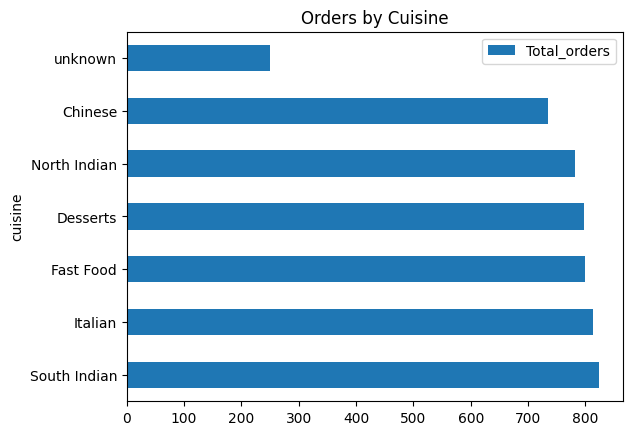

In [51]:
df.plot(x='cuisine', y='Total_orders', kind='barh')
plt.title('Orders by Cuisine')
plt.show()

Certain cuisines dominate order volume, reflecting strong customer demand and preference trends.

Total order by cities

In [12]:
tobc = """ 
select cat__city as city,
count(order_id) total_orders
from swaggy_db
group by cat__city
order by total_orders desc;

"""

d5 = pd.read_sql(tobc,conn)
d5

,city,total_orders
0,Mumbai,820
1,Chennai,814
2,Delhi,789
3,Kolkata,785
4,Hyderabad,775
5,Bangalore,767
6,unknown,250


Order distribution varies by city, with some cities acting as major demand hubs for the platform.

Total Revenue generated by cites

In [37]:
trbc = """ 
select cat__city as city,
sum(num__order_amount) total_revenue
from swaggy_db
group by cat__city
order by total_revenue desc;

"""

df = pd.read_sql(trbc,conn)
df

,city,total_revenue
0,Chennai,656688.11
1,Mumbai,650046.17
2,Hyderabad,630072.60
3,Delhi,623256.62
4,Kolkata,622145.42
5,Bangalore,605951.25
6,unknown,189669.65


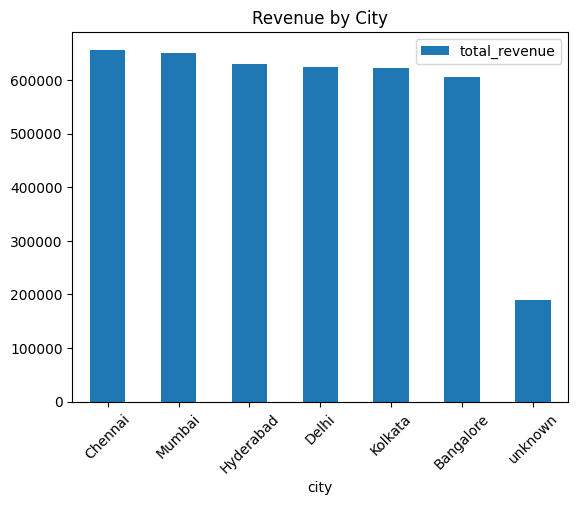

In [39]:
df = pd.read_sql(trbc, conn)

df.plot(x='city', y='total_revenue', kind='bar')
plt.title('Revenue by City')
plt.xticks(rotation=45)
plt.show()

City Chennai contributes the highest revenue, making it the most important market. The business should focus on strengthening operations and marketing in this region.

Average Delivery Time per city

In [66]:
adtpc = """ 
select cat__city as city,
avg(num__delivery_time_mins) as average_delivery_time
from swaggy_db
group by cat__city
order by avg(num__delivery_time_mins) desc;
"""
df = pd.read_sql(adtpc,conn)
df

,city,average_delivery_time
0,Delhi,35.144487
1,Kolkata,35.141401
2,unknown,35.020000
3,Bangalore,34.870926
4,Hyderabad,34.247742
5,Chennai,33.791155
6,Mumbai,33.776829


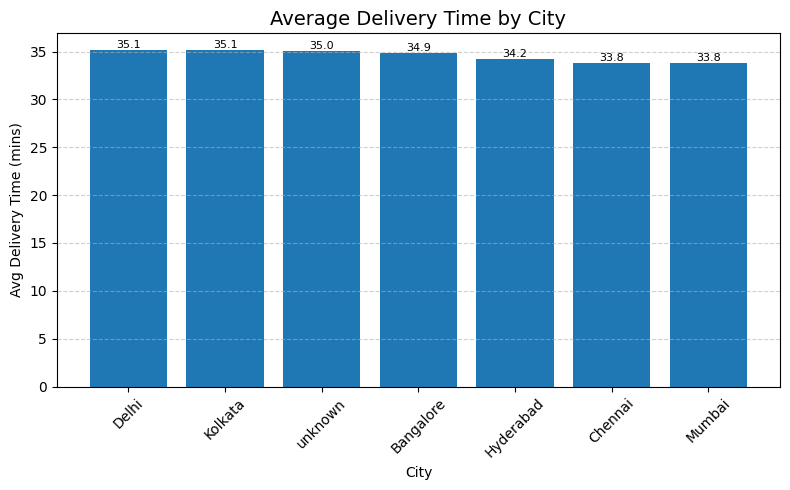

In [69]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    df['city'],
    df['average_delivery_time']
)

plt.title('Average Delivery Time by City', fontsize=14)
plt.xlabel('City')
plt.ylabel('Avg Delivery Time (mins)')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

Cities with higher average delivery times may face logistical inefficiencies, which can negatively impact customer satisfaction.

Most cancelled orders cities

In [15]:
mocc = """ 
with vt as (
select order_id,cat__order_status,cat__city
from swaggy_db
where cat__order_status in('Cancelled')
)
select cat__city,count(order_id) as total_cancel_order
from vt 
group by cat__city
order by count(order_id) desc;
"""
d13 = pd.read_sql(mocc,conn)
d13

,cat__city,total_cancel_order
0,Hyderabad,276
1,Mumbai,275
2,Delhi,267
3,Chennai,267
4,Bangalore,259
5,Kolkata,241
6,unknown,96


Certain cities show higher cancellation counts, possibly due to delays or operational inefficiencies, requiring focused improvement.

Top 3 High Revenue generated cities

In [16]:
t3hrc = """ 

select cat__city as city,
sum(num__order_amount) Total_revenue
from swaggy_db
group by cat__city
order by Total_revenue desc limit 3;
"""
pd.read_sql(t3hrc,conn)

,city,Total_revenue
0,Chennai,656688.11
1,Mumbai,650046.17
2,Hyderabad,630072.60


Top 3 High Rating generated cities

In [17]:
t3hratc = """ 

select cat__city as city,
avg(num__rating) rating
from swaggy_db
group by cat__city
order by rating desc limit 3;
"""
pd.read_sql(t3hratc,conn)

,city,rating
0,Kolkata,3.047643
1,Chennai,3.036364
2,Delhi,3.034854


Order cancelled Vs Average delivery time by city

In [63]:
ocvadtbc = """ 
with vt as (
select order_id,cat__order_status,cat__city,num__delivery_time_mins
from swaggy_db
where cat__order_status in('Cancelled')
)
select 
cat__city as city,
count(order_id) as total_cancel_order,
avg(num__delivery_time_mins) as average_delivery_time
from vt 
group by cat__city
order by count(order_id) desc;
"""
df= pd.read_sql(ocvadtbc,conn)
df

,city,total_cancel_order,average_delivery_time
0,Hyderabad,276,35.322464
1,Mumbai,275,34.047273
2,Delhi,267,34.940075
3,Chennai,267,34.456929
4,Bangalore,259,34.872587
5,Kolkata,241,34.157676
6,unknown,96,35.218750


Cities with higher average delivery times tend to have more cancellations, suggesting delays as a key contributing factor.

Revenue generated by each Restaurants

In [20]:
trgr = """ 

select cat__restaurant as Restaurants,
sum(num__order_amount) Revenue
from swaggy_db
group by cat__restaurant
order by Revenue desc;

"""
d8 = pd.read_sql(trgr,conn)
d8

,Restaurants,Revenue
0,Pizza World,673567.03
1,Spice Hub,651400.63
2,Foodies Point,623901.15
3,Sushi Zen,613723.86
4,Urban Tadka,612135.95
5,Biryani House,601459.70
6,unknown,201641.50


Restaurants like Pizza World, Spice Hub, and Foodies Point are top revenue contributors, indicating strong customer preference and performance. These partners should be prioritized.

Average Rating by each Restaurants

In [21]:
arpr = """SELECT 
    cat__restaurant as Restaurant,
    AVG(num__rating) AS average_rating,
    DENSE_RANK() OVER (ORDER BY AVG(num__rating) DESC) AS ranking
FROM swaggy_db
GROUP BY cat__restaurant;"""

d9 = pd.read_sql(arpr,conn)
d9

,Restaurant,average_rating,ranking
0,Urban Tadka,3.095817,1
1,Foodies Point,3.057503,2
2,unknown,3.014800,3
3,Sushi Zen,3.005388,4
4,Spice Hub,3.000851,5
5,Pizza World,3.000244,6
6,Biryani House,2.999607,7


Some restaurants have significantly lower ratings, indicating potential issues in food quality or service that need improvement.

Most Cancelled orders Restaurants

In [22]:
mcor = """ 
with vt as (
select order_id,cat__order_status as cancelled_orders,cat__restaurant as restaurant from swaggy_db where cat__order_status in('Cancelled'))
select restaurant,count(order_id) as total_cancelled_orders from vt
group by restaurant
order by count(order_id) desc;
"""
d15 = pd.read_sql(mcor,conn)
d15

,restaurant,total_cancelled_orders
0,Pizza World,278
1,Biryani House,275
2,Urban Tadka,272
3,Foodies Point,271
4,Spice Hub,256
5,Sushi Zen,242
6,unknown,87


Certain restaurants have higher cancellation counts, indicating possible operational inefficiencies or service issues.

Average Delivery time per Restaurants

In [28]:
adpr = """ 
select cat__restaurant as restaurant,
avg(num__delivery_time_mins) as Average_delivery_time
from swaggy_db
group by cat__restaurant
order by avg(num__delivery_time_mins) desc;

"""
pd.read_sql(adpr,conn)

,restaurant,Average_delivery_time
0,Sushi Zen,36.394218
1,Urban Tadka,34.577947
2,Biryani House,34.467890
3,Foodies Point,34.045397
4,Pizza World,34.003654
5,Spice Hub,33.895504
6,unknown,33.892000


Delivery time varies significantly across restaurants, highlighting differences in operational efficiency.

Top 3 High Rating Restaurants

In [23]:
t3hrr = """ 

select cat__restaurant as restaurant,
avg(num__rating) rating
from swaggy_db
group by cat__restaurant
order by rating desc limit 3;
"""
pd.read_sql(t3hrr,conn)

,restaurant,rating
0,Urban Tadka,3.095817
1,Foodies Point,3.057503
2,unknown,3.014800


Order_status Vs Avg_delivery_time

In [24]:
ocvdtbr = """ 
SELECT 
   cat__order_status,
    AVG(num__delivery_time_mins) AS avg_delivery_time
FROM swaggy_db
GROUP BY cat__order_status
order by AVG(num__delivery_time_mins) desc;
"""
d16 = pd.read_sql(ocvdtbr,conn)
d16

,cat__order_status,avg_delivery_time
0,Cancelled,34.673409
1,Pending,34.513806
2,Delivered,34.346642


Cancelled orders generally have higher delivery times compared to delivered ones, showing a strong relationship between delays and cancellations.

Correlation between Delivery time and Rating

In [25]:
dtar = """ 

select case
 when num__delivery_time_mins < 20 then 'fast'
 when num__delivery_time_mins between 20 and 40 then 'medium'
 else 'slow' 
 end as delivery_speed,
 AVG(num__rating) AS avg_rating
 from swaggy_db
 group by delivery_speed;

"""
pd.read_sql(dtar,conn)

,delivery_speed,avg_rating
0,fast,3.040041
1,medium,3.021175
2,slow,3.024059


Orders with faster delivery times tend to have higher ratings, showing that delivery speed is a key factor in customer satisfaction.

Revenue generated by each cuisine

In [40]:
rbc = """ 
select cat__cuisine as cuisine, sum(num__order_amount) Revenue
from swaggy_db
group by cat__cuisine 
order by Revenue desc;
"""
pd.read_sql(rbc,conn)

,cuisine,Revenue
0,South Indian,651799.65
1,Fast Food,648347.13
2,Italian,640327.89
3,North Indian,633533.88
4,Desserts,619371.65
5,Chinese,571930.62
6,unknown,212519.00


Cuisine South indians generates the highest revenue, indicating strong customer demand. Expanding options in this category can drive further growth.

Delivery time on the bases of cuisine

In [30]:
dtobc = """ 
select cat__cuisine,
avg(num__delivery_time_mins) average_delivery_time
from swaggy_db
group by cat__cuisine
order by average_delivery_time desc;
"""
pd.read_sql(dtobc,conn)

,cat__cuisine,average_delivery_time
0,North Indian,35.291933
1,Chinese,34.912925
2,South Indian,34.898058
3,Fast Food,34.752190
4,unknown,34.728000
5,Desserts,33.748120
6,Italian,33.457565


Some cuisines take longer to prepare and deliver, which may affect customer satisfaction and ratings.

Average rating for each each cuisine

In [31]:
arec = """  
select cat__cuisine,
avg(num__rating) as Avg_rating
from swaggy_db
group by cat__cuisine
order by avg(num__rating) desc;
"""
pd.read_sql(arec,conn)

,cat__cuisine,Avg_rating
0,Chinese,3.043537
1,Italian,3.037515
2,Desserts,3.032080
3,North Indian,3.029834
4,Fast Food,3.028911
5,South Indian,2.997937
6,unknown,2.987200


Certain cuisines consistently receive higher ratings, indicating better customer satisfaction and perceived quality.